In [2]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from utils.video_utils import compute_optical_flow

In [ ]:
DATA_ROOT = "../data/UCSD_Anomaly_Dataset/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test001"

frames = sorted([
    os.path.join(DATA_ROOT, f)     # f is the filename
    for f in os.listdir(DATA_ROOT)
    if f.endswith(".tif")
])

print("Total frames:", len(frames))


Total frames: 180


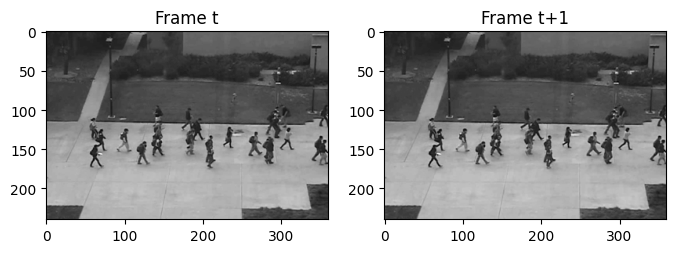

In [5]:
frame1 = cv2.imread(frames[10], cv2.IMREAD_GRAYSCALE)
frame2 = cv2.imread(frames[11], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(frame1, cmap="gray")
plt.title("Frame t")

plt.subplot(1,2,2)
plt.imshow(frame2, cmap="gray")
plt.title("Frame t+1")
plt.show()


In [6]:
mag, ang = compute_optical_flow(frame1, frame2)


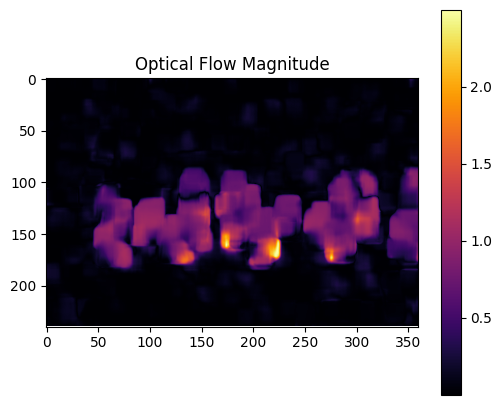

In [7]:
plt.figure(figsize=(6,5))
plt.imshow(mag, cmap="inferno")
plt.colorbar()
plt.title("Optical Flow Magnitude")
plt.show()


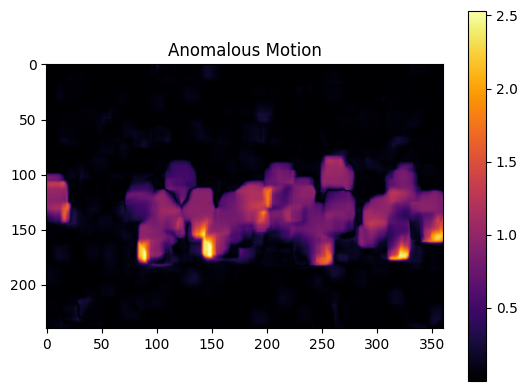

In [ ]:
# Try frames where anomaly happens
frame1 = cv2.imread(frames[50], cv2.IMREAD_GRAYSCALE)
frame2 = cv2.imread(frames[51], cv2.IMREAD_GRAYSCALE)

mag, _ = compute_optical_flow(frame1, frame2)

plt.imshow(mag, cmap="inferno")
plt.title("Anomalous Motion")
plt.colorbar()
plt.show()


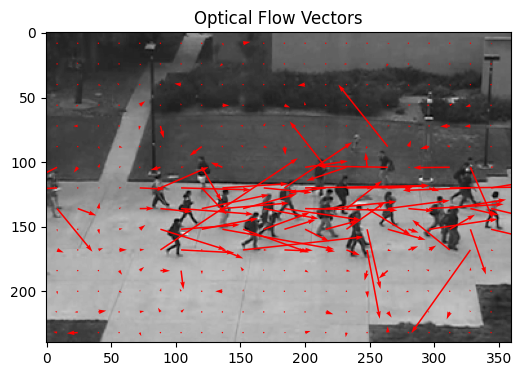

In [ ]:
step = 16          # it is like one line for every 16 pixels
h, w = mag.shape   # mag is 2D array with shape (height, width)

y, x = np.mgrid[step//2:h:step, step//2:w:step]  # slicing the grid [start : stop : step]
fx = mag[y, x] * np.cos(ang[y, x])     # optical flow was converted to polar coordinates now converting back to Cartesian for horizontal component fx
fy = mag[y, x] * np.sin(ang[y, x])     # optical flow was converted to polar coordinates now converting back to Cartesian for vertical component fy 

plt.figure(figsize=(6,5))
plt.imshow(frame1, cmap='gray')
plt.quiver(x, y, fx, fy, color='red')
plt.title("Optical Flow Vectors")
plt.show()
